In [4]:
!pip uninstall -y numpy
#surprise works only with NumPy 1.x                   # Uninstall the current version of Numpy
!pip install numpy==1.26.4                           # Install numpy version 1.26.4
!pip install scikit-surprise --prefer-binary         # Install surprise library now

#scikit-surprise (or simply Surprise) is a Python library used to build Recommendation Systems.
#It is mainly used for collaborative filtering — like Netflix, Amazon, YouTube recommendations.

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# install numpy
!pip install surprise
from surprise import Reader,SVD,Dataset
from surprise.model_selection import cross_validate

In [6]:
Netflix_df = pd.read_csv("/content/drive/MyDrive/combined_data_1.txt",header=None, names =['Customer_Id','Rating'],usecols=[0,1])
Netflix_df

,Customer_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [7]:
Netflix_df.shape

(24058263, 2)

In [8]:
Netflix_df.head(5)

,Customer_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [9]:
Netflix_df.tail(5)

,Customer_Id,Rating
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0
24058262,1704416,3.0


In [10]:
Netflix_df.dtypes

,0
Customer_Id,object
Rating,float64


In [11]:
Netflix_df.isnull().sum()

,0
Customer_Id,0
Rating,4499


In [12]:
Movie_count = Netflix_df.isnull().sum()
Movie_count = Movie_count['Rating']
print(Movie_count)

4499


In [13]:
Customer_count = Netflix_df['Customer_Id'].nunique()
Customer_count

475257

In [14]:
print(Customer_count - Movie_count)  # Total number of customers that we have after removing movie id from the column

470758


In [15]:
# Total Number of rarings given by Customers
Rating_count = Netflix_df['Customer_Id'].count() - Movie_count
print(Rating_count)

24053764


In [16]:
# find out the how many stars given by people like 1,2,3,4,5
Stars = Netflix_df.groupby('Rating')['Rating'].agg('count')
print(Stars)

Rating
1.0    1118186
2.0    2439073
3.0    6904181
4.0    8085741
5.0    5506583
Name: Rating, dtype: int64


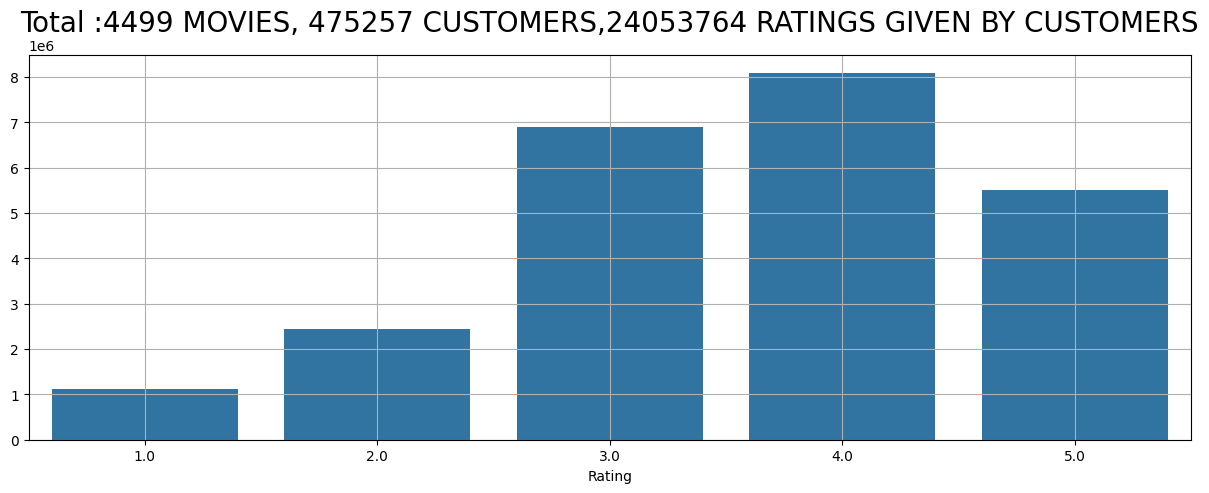

In [53]:
plt.figure(figsize=(15,5))
sns.barplot(x=Stars.index, y=Stars.values)
plt.title(f'Total :{Movie_count} MOVIES, {Customer_count} CUSTOMERS,{Rating_count} RATINGS GIVEN BY CUSTOMERS',fontsize=20)
plt.grid(True)
plt.show()

In [18]:
Netflix_df['Customer_Id']

,Customer_Id
0,1:
1,1488844
2,822109
3,885013
4,30878
...,...
24058258,2591364
24058259,1791000
24058260,512536
24058261,988963


In [19]:
#LET'S MMAKE A CLEAR DATAFRAME OF DATASET
Movie_Id = None
Movie_np = []

for id in Netflix_df['Customer_Id']:
    if ':' in id:
        Movie_Id = int(id.replace(':',''))
    Movie_np.append(Movie_Id)

In [20]:
Movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [21]:
# To add the new column in Dataframe
Netflix_df['Movie_Id'] = Movie_np

In [22]:
Netflix_df

,Customer_Id,Rating,Movie_Id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [23]:
#To keep only rows where Rating is not null
Netflix_df = Netflix_df[Netflix_df['Rating'].notna()]
Netflix_df

,Customer_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [24]:
Netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Customer_Id  object 
 1   Rating       float64
 2   Movie_Id     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [25]:
#Now we don't have Movie let's the fix Xustomer_Id Datatype
Netflix_df['Customer_Id'] = Netflix_df['Customer_Id'].astype(int)

/tmp/ipykernel_11920/241644020.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Netflix_df['Customer_Id'] = Netflix_df['Customer_Id'].astype(int)


In [26]:
Netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Customer_Id  int64  
 1   Rating       float64
 2   Movie_Id     int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [27]:
#PRE-FILTERING
Movie_summary = Netflix_df.groupby('Movie_Id')['Rating'].agg(["count"])
Cust_summary = Netflix_df.groupby('Customer_Id')['Rating'].agg(['count'])

In [28]:
# NOW we wil create a benchmark for movie and customer
Movie_BM = round(Movie_summary['count'].quantile(0.6),0)
Customer_BM = round(Cust_summary['count'].quantile(0.6),0)

In [29]:
# Now we will drop whose Movies less than the benchmark and in-active customers
drop_movie_list = Movie_summary[Movie_summary['count']< Movie_BM].index
drop_cust_list = Cust_summary[Cust_summary['count']< Customer_BM].index

In [30]:
print(len(drop_cust_list))

282042


In [31]:
print(len(drop_movie_list))

2699


In [32]:
## CLEAN DATASET
Netflix_df = Netflix_df[~Netflix_df['Movie_Id'].isin(drop_movie_list)]
Netflix_df = Netflix_df[~Netflix_df['Customer_Id'].isin(drop_cust_list)]
Netflix_df

,Customer_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [33]:
Netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19695836 entries, 696 to 24056846
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Customer_Id  int64  
 1   Rating       float64
 2   Movie_Id     int64  
dtypes: float64(1), int64(2)
memory usage: 601.1 MB


# **Model Building**

In [34]:
df_title = pd.read_csv("/content/drive/MyDrive/movie_titles _1_.csv", encoding = 'latin',header =None, usecols =[0,1,2],names= ['Movie_ID','Year','Name'])
df_title

,Movie_ID,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [37]:
reader =Reader(rating_scale=(1,5))

In [38]:
# I'm working with 100k data for quick runtime

data = Dataset.load_from_df(Netflix_df[['Customer_Id','Movie_Id','Rating']][:100000],reader)

In [39]:
model = SVD()

In [40]:
# Train the model
cross_validate(model,data,measures=['RMSE'],cv=3)

{'test_rmse': array([1.01246377, 1.02411234, 1.01831069]),
 'fit_time': (1.6379811763763428, 2.6441402435302734, 5.124504804611206),
 'test_time': (0.15221047401428223, 0.869945764541626, 1.5108897686004639)}

# **Most Popular Movies**

In [42]:
popular_movies = Netflix_df['Movie_Id'].value_counts().head(10)

popular_movies = popular_movies.reset_index()
popular_movies.columns = ['Movie_Id','Count']

popular_movies = popular_movies.merge(df_title, left_on='Movie_Id', right_on='Movie_ID')

print(popular_movies[['Name','Count']])

                                                Name   Count
0  Pirates of the Caribbean: The Curse of the Bla...  142993
1      Lord of the Rings: The Fellowship of the Ring  121278
2                                    American Beauty  120186
3                                    The Sixth Sense  119073
4                                     Bruce Almighty  118609
5                                    The Italian Job  113853
6                                            Shrek 2  112016
7                          Finding Nemo (Widescreen)  111102
8                           The Silence of the Lambs  109025
9                                         Braveheart  106472


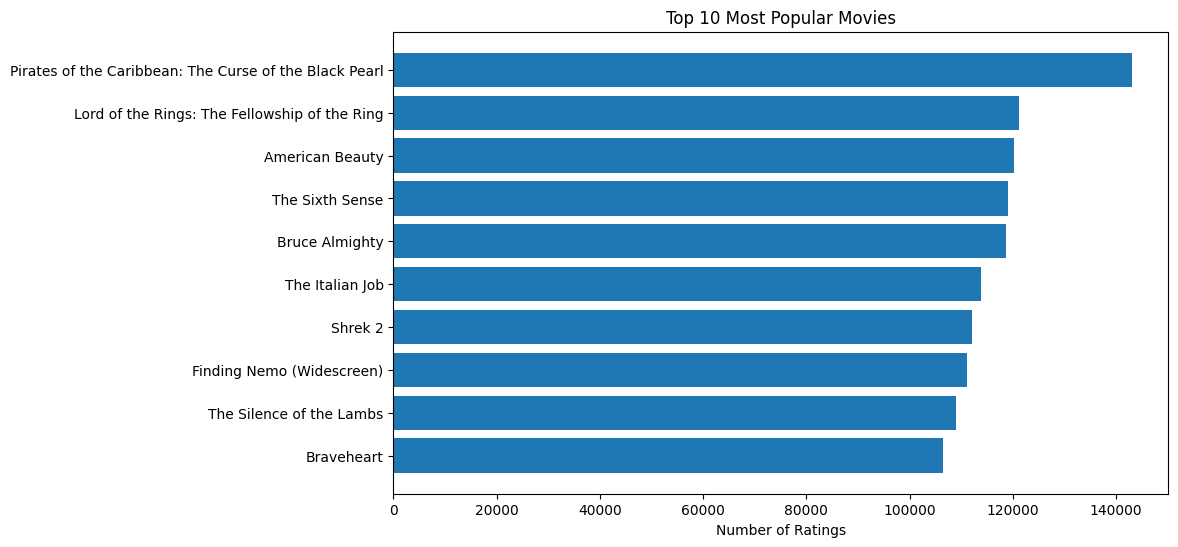

In [52]:
plt.figure(figsize=(10,6))
plt.barh(popular_movies['Name'], popular_movies['Count'])
plt.title("Top 10 Most Popular Movies")
plt.xlabel("Number of Ratings")
plt.gca().invert_yaxis()
plt.show()

## **2. Best Movie Recommendation (using SVD)**

In [47]:
def recommend_movies(user_id):

    # 1. Movies already watched by user
    watched = Netflix_df[Netflix_df['Customer_Id'] == user_id]['Movie_Id'].tolist()

    # 2. Get all movies
    all_movies = Netflix_df['Movie_Id'].unique()

    # 3. Find movies user has NOT watched
    unseen = []
    for movie in all_movies:
        if movie not in watched:
            unseen.append(movie)

    # 4. Predict rating for each unseen movie
    predictions = []
    for movie in unseen:
        pred = model.predict(user_id, movie)
        predictions.append((movie, pred.est))  # (movie_id, predicted_rating)

    # 5. Sort by highest predicted rating
    predictions.sort(key=lambda x: x[1], reverse=True)

    # 6. Take top 5 movies
    top_movies = predictions[:5]

    # 7. Convert Movie_Id → Name
    result = []
    for movie_id, rating in top_movies:
        name = df_title[df_title['Movie_ID'] == movie_id]['Name'].values[0]
        result.append(name)

    return result

In [48]:
recommend_movies(712664)

['Inspector Morse 31: Death Is Now My Neighbour',
 'The Rise and Fall of ECW',
 'Lilo and Stitch',
 "Something's Gotta Give",
 "ABC Primetime: Mel Gibson's The Passion of the Christ"]

# **Best & Worst Movies**

In [44]:
movie_avg = Netflix_df.groupby('Movie_Id')['Rating'].mean().reset_index()

movie_avg = movie_avg.merge(df_title, left_on='Movie_Id', right_on='Movie_ID')

best_movies = movie_avg.sort_values(by='Rating', ascending=False).head(10)
worst_movies = movie_avg.sort_values(by='Rating').head(10)

print("Best Movies:\n", best_movies[['Name','Rating']])
print("\nWorst Movies:\n", worst_movies[['Name','Rating']])

Best Movies:
                                                Name    Rating
1376                                 Lost: Season 1  4.667269
832                          The Simpsons: Season 6  4.588016
1370          Family Guy: Freakin' Sweet Collection  4.520370
1681                                      Inu-Yasha  4.495253
595                        Six Feet Under: Season 4  4.466834
1033                        Stargate SG-1: Season 8  4.463280
1771                        The West Wing: Season 3  4.456323
777                         Gilmore Girls: Season 3  4.438146
521                     The Best of Friends: Vol. 4  4.436311
986   Lord of the Rings: The Fellowship of the Ring  4.433863

Worst Movies:
                                              Name    Rating
1459                            Shanghai Surprise  1.755993
1196                            House of the Dead  1.962401
1758                                       Druids  2.012658
906                                   Spice Worl